# Project 2 — Modeling and Predicting King County House Prices Using Python

**Gan Zheng Hong**  
**DAT 301**  
**1/3/2026**  

# 1. Abstract

This project analyzes residential housing sales data from King County, Washington, to determine which property characteristics most strongly influence house prices. Using Python and data science techniques, I reimplement and extend my previous analysis by performing data cleaning, exploratory data analysis, and predictive modeling entirely in pandas, matplotlib, and scikit-learn. I focus on modeling the logarithm of house price to improve linear model assumptions and predictive accuracy. Several models are compared, including ordinary least squares (OLS), regularized linear models, and a random forest regressor. Model performance is evaluated using out-of-sample RMSE and R², and the final model is interpreted in terms of economic and practical significance.

# 2. Introduction & Research Questions

Housing prices are influenced by a combination of structural features, location characteristics, and market conditions. Understanding how these factors contribute to property values is important for buyers, sellers, real estate professionals, and policymakers.

This project uses a dataset of residential home sales in King County, Washington. The goal is to quantitatively determine which features most strongly predict house prices and to evaluate how accurately different statistical and machine learning models can estimate property values.

The primary research questions are:

- RQ1: Which structural and location-related features most strongly predict house prices in King County?
- RQ2: After controlling for other variables, how much does an increase in living area (sqft_living) affect house price?
- RQ3: Which predictive model (OLS, regularized linear regression, or random forest) provides the best out-of-sample prediction accuracy?

These questions will be addressed through systematic data cleaning, exploratory analysis, and quantitative modeling.

# 3. Data

The dataset used in this project is the King County housing dataset (kc_house_data.csv), which contains detailed information on residential home sales in King County, Washington.

The dataset includes variables such as:

- price: Sale price of the house
- bedrooms: Number of bedrooms
- bathrooms: Number of bathrooms
- sqft_living: Square footage of interior living space
- sqft_lot: Lot size
- floors: Number of floors
- waterfront: Whether the property is on the waterfront (binary)
- view: Quality of view rating
- grade: Overall construction and design grade
- yr_built: Year built
- zipcode: Zip code of the property
- lat and long: Geographic coordinates
- date: Date of sale

The dataset contains over 1,000 observations (in fact, more than 20,000), satisfying the project requirement for a sufficiently large sample size.

Source:
King County Housing Dataset (publicly available dataset frequently used for regression modeling practice).  
URL: https://www.kaggle.com/datasets/harlfoxem/housesalesprediction

# 4. Data Loading & Verification

The dataset will be loaded locally using pandas with a relative file path to ensure reproducibility. All verification steps will be performed programmatically using Python functions rather than manual inspection.

The following checks will be conducted:

- Confirm dataset dimensions (rows and columns)
- Inspect data types of all variables
- Identify missing values using isna()
- Detect duplicate rows using duplicated()
- Verify reasonable value ranges for numeric variables
- Convert the date column to datetime format

Additionally, a new variable, log_price, will be created as the natural logarithm of price. This transformation is expected to improve linear model assumptions by reducing skewness in the dependent variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("kc_house_data.csv")
display(df.head())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Load libraries and dataset (relative path)
The cell below imports the libraries we will use and loads `kc_house_data.csv` from the current directory.

In [2]:
# basic imports and load dataset
import pandas as pd
import numpy as np

# plotting (we'll use these later)
import matplotlib.pyplot as plt
import seaborn as sns

# make plots appear inline in the notebook
%matplotlib inline

# load dataset (relative path)
df = pd.read_csv("kc_house_data.csv")

# quick confirmation that load succeeded
# use display for nicer rendering where useful
print("Data loaded. Use the following cells to inspect the dataset.")

Data loaded. Use the following cells to inspect the dataset.


## Quick shape + column list + first rows
Check how many rows and columns there are, the column names, and see the first 5 rows to confirm the data looks like the King County dataset.

In [3]:
# shape and columns
display(pd.DataFrame({
    "rows": [df.shape[0]],
    "columns": [df.shape[1]]
}))

# list columns
display(pd.Series(df.columns.tolist(), name="columns"))

# first 5 rows (display is preferred)
display(df.head())

,rows,columns
0,21613,21


0                id
1              date
2             price
3          bedrooms
4         bathrooms
5       sqft_living
6          sqft_lot
7            floors
8        waterfront
9              view
10        condition
11            grade
12       sqft_above
13    sqft_basement
14         yr_built
15     yr_renovated
16          zipcode
17              lat
18             long
19    sqft_living15
20       sqft_lot15
Name: columns, dtype: object

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Data types and info
Check datatypes for each column and the memory summary. This also helps us find object columns that should be date or numeric.

In [4]:
# datatypes
display(df.dtypes)

# info() prints summary to stdout (that's fine)
df.info()

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

## Missing values check (programmatic)
Show columns that have any missing values and their counts, plus percentage missing per column.

In [5]:
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

# display columns with missing values (if any)
if len(missing_counts) == 0:
    display("No missing values detected in any column.")
else:
    display(missing_counts)

# show percentage missing for all columns (helpful)
pct_missing = df.isna().mean().sort_values(ascending=False)
display((pct_missing[pct_missing>0] * 100).round(3).rename("percent_missing"))

'No missing values detected in any column.'

Series([], Name: percent_missing, dtype: float64)

## Duplicate rows check
If duplicate observations exist, we will inspect them and optionally remove them. For now, we only count them.

In [6]:
dup_count = df.duplicated().sum()
display(pd.DataFrame({"duplicate_rows": [dup_count]}))
# if there are duplicates, show a small sample of duplicates to inspect
if dup_count > 0:
    display(df[df.duplicated(keep=False)].sample(min(10, dup_count), random_state=2026))

,duplicate_rows
0,0


## Sanity checks for obvious out-of-range values
Programmatically check some sensible ranges for numeric fields (you can adjust thresholds later). 
We will *not* drop anything yet — this is to detect weird values that need investigation.

In [7]:
checks = {
    "bedrooms_gt_20": (df['bedrooms'] > 20).sum() if 'bedrooms' in df.columns else np.nan,
    "bathrooms_eq_0": (df['bathrooms'] == 0).sum() if 'bathrooms' in df.columns else np.nan,
    "sqft_living_eq_0": (df['sqft_living'] == 0).sum() if 'sqft_living' in df.columns else np.nan,
    "price_eq_0": (df['price'] == 0).sum() if 'price' in df.columns else np.nan,
    "zipcode_null": df['zipcode'].isna().sum() if 'zipcode' in df.columns else np.nan
}
display(pd.Series(checks, name="count"))

bedrooms_gt_20       1
bathrooms_eq_0      10
sqft_living_eq_0     0
price_eq_0           0
zipcode_null         0
Name: count, dtype: int64

## Convert date column to datetime (if needed) and show updated dtypes
We will convert the 'date' column to datetime if it is not already. If conversion fails, inspect the sample values first.

In [8]:
if 'date' in df.columns:
    # check current dtype
    display(pd.DataFrame({"before_dtype": [df['date'].dtype]}))
    # attempt conversion (errors='coerce' will set unparsable entries to NaT)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    display(pd.DataFrame({"after_dtype": [df['date'].dtype]}))
    # show any rows where date conversion failed
    bad_dates = df['date'].isna().sum()
    display(pd.DataFrame({"date_parse_errors": [bad_dates]}))
else:
    display("No 'date' column found in dataset.")

,before_dtype
0,object


,after_dtype
0,datetime64[ns]


,date_parse_errors
0,0


## Short summary statistics for key numeric columns
We will display `describe()` for numeric columns to check ranges, means, and look for suspicious values.

In [9]:
display(df.select_dtypes(include=[np.number]).describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1000102.000,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,75000.000,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.371000e+00,9.300000e-01,0.000,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.115000e+00,7.700000e-01,0.000,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184410e+02,290.000,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,520.000,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494000e+00,5.400000e-01,1.000,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,8.000000e-03,8.700000e-02,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.340000e-01,7.660000e-01,0.000,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409000e+00,6.510000e-01,1.000,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


# 5. Data Cleaning

Data cleaning will be conducted entirely through code to ensure transparency and reproducibility.

The cleaning process will include:

- Converting the date column to datetime format
- Removing duplicate observations if present
- Checking for and handling missing values
- Verifying that numeric variables fall within reasonable ranges
- Removing extreme or unrealistic values when justified
- Creating derived variables such as log_price

Each transformation will be clearly documented and justified in the accompanying text. No manual editing of the dataset will be performed outside of the notebook.

## Handling Extreme and Implausible Values

Although no missing values or duplicate rows were detected, several potentially unrealistic values were identified during sanity checks. Specifically:

- One observation has more than 20 bedrooms.
- Several observations have 0 bathrooms.

These values may distort regression estimates and will be handled programmatically.

In [10]:
# inspect extreme bedroom values
display(df[df['bedrooms'] > 20])

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15870,2402100895,2014-06-25,640000.0,33,1.75,1620,6000,1.0,0,0,...,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


The dataset contains one observation with more than 20 bedrooms. This is highly unusual and likely represents a data entry error or a non-typical property. Because such an extreme value may unduly influence regression estimates, this observation will be removed.

In [11]:
# remove extreme bedroom outlier
df = df[df['bedrooms'] <= 20]

# confirm removal
display((df['bedrooms'] > 20).sum())

np.int64(0)

In [12]:
# inspect houses with 0 bathrooms
display(df[df['bathrooms'] == 0].head())
print("Number of 0-bathroom houses:", (df['bathrooms'] == 0).sum())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
875,6306400140,2014-06-12,1095000.0,0,0.0,3064,4764,3.5,0,2,...,7,3064,0,1990,0,98102,47.6362,-122.322,2360,4000
1149,3421079032,2015-02-17,75000.0,1,0.0,670,43377,1.0,0,0,...,3,670,0,1966,0,98022,47.2638,-121.906,1160,42882
3119,3918400017,2015-02-05,380000.0,0,0.0,1470,979,3.0,0,2,...,8,1470,0,2006,0,98133,47.7145,-122.356,1470,1399
5832,5702500050,2014-11-04,280000.0,1,0.0,600,24501,1.0,0,0,...,3,600,0,1950,0,98045,47.5316,-121.749,990,22549
6994,2954400190,2014-06-24,1295650.0,0,0.0,4810,28008,2.0,0,0,...,12,4810,0,1990,0,98053,47.6642,-122.069,4740,35061


Number of 0-bathroom houses: 10


Several houses report zero bathrooms. While rare, these entries likely represent incomplete or erroneous records. Since bathrooms are a key structural variable in pricing models, observations with zero bathrooms will be removed to avoid distortions in the regression analysis.

In [13]:
# remove 0-bathroom houses
df = df[df['bathrooms'] > 0]

# confirm removal
display((df['bathrooms'] == 0).sum())

np.int64(0)

In [14]:
import numpy as np

df['log_price'] = np.log(df['price'])

display(df[['price', 'log_price']].head())

,price,log_price
0,221900.0,12.309982
1,538000.0,13.195614
2,180000.0,12.100712
3,604000.0,13.311329
4,510000.0,13.142166


A natural logarithm transformation of price is created to reduce skewness and improve linear regression assumptions. In log-linear models, coefficient estimates can be interpreted approximately as percentage changes in price.

In [15]:
# final dataset size after cleaning
display(pd.DataFrame({
    "rows_after_cleaning": [df.shape[0]],
    "columns_after_cleaning": [df.shape[1]]
}))

,rows_after_cleaning,columns_after_cleaning
0,21602,22


After removing extreme bedroom values and observations with zero bathrooms, the dataset remains large and suitable for modeling.

# 6. Exploratory Data Analysis (EDA)

The exploratory data analysis (EDA) section will examine the distribution and relationships among variables to gain intuition about the dataset.

Planned visualizations include:

- Histogram of price and log_price to examine skewness
- Scatterplots of sqft_living versus price and log_price
- Boxplots of price by grade and waterfront status
- Correlation heatmap of key numeric variables
- Additional visualizations as needed to better understand relationships

Each visualization will be accompanied by a written interpretation explaining what patterns are observed and how they relate to the research questions.

## Distribution of Price and Log-Transformed Price

Before modeling, it is important to examine the distribution of the dependent variable. 
House prices are typically right-skewed, which can violate linear regression assumptions. 
To address this, we created a log transformation of price.

The following plots compare the raw price distribution with the log-transformed distribution.

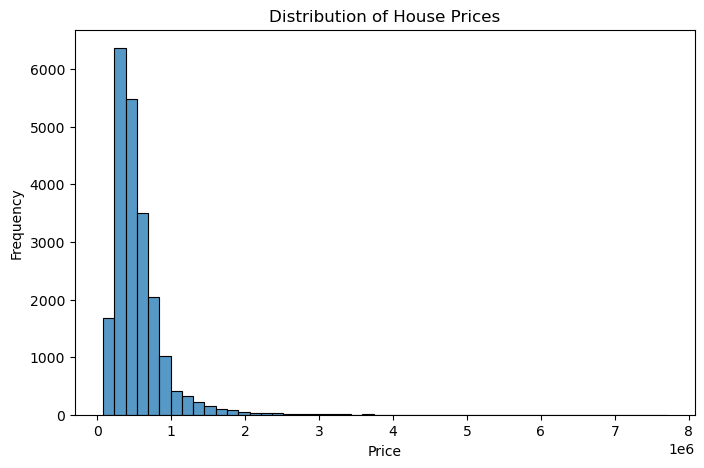

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

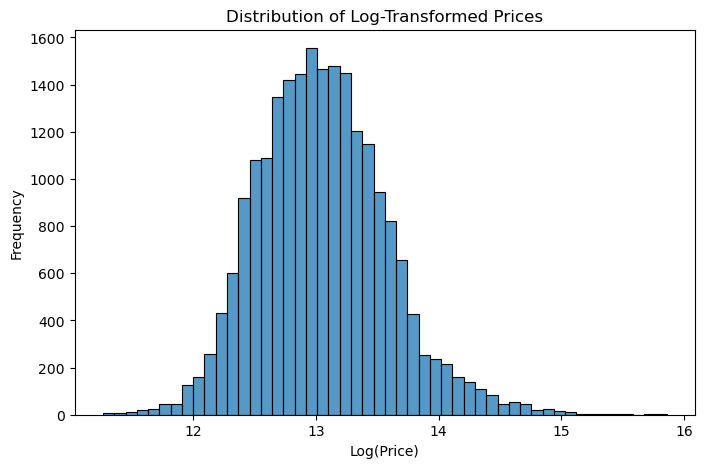

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['log_price'], bins=50)
plt.title("Distribution of Log-Transformed Prices")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")
plt.show()

The raw price distribution is strongly right-skewed, with a long upper tail driven by high-value properties. 
Such skewness can violate the normality and homoscedasticity assumptions of linear regression.

After applying a logarithmic transformation, the distribution becomes much more symmetric and closer to normal. 
This supports the use of log_price as the dependent variable in subsequent regression models.

## Relationship Between Living Area and House Price

One of the most important structural variables in housing markets is the interior living area (sqft_living). 

We examine the relationship between living area and both raw price and log-transformed price to understand whether the relationship appears linear and suitable for regression modeling.

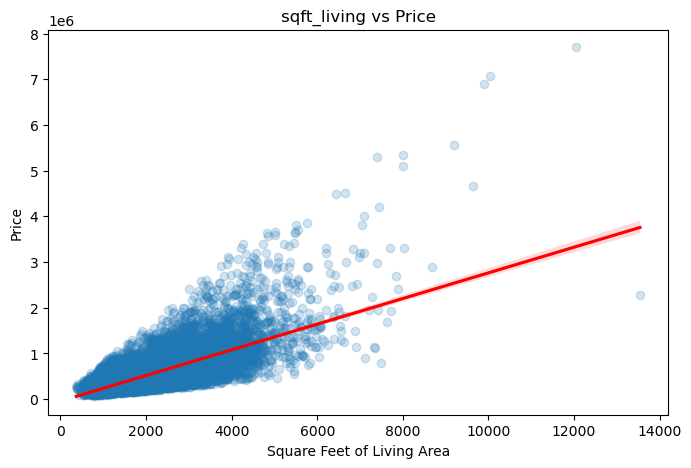

In [18]:
plt.figure(figsize=(8,5))
sns.regplot(
    x='sqft_living',
    y='price',
    data=df,
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)
plt.title("sqft_living vs Price")
plt.xlabel("Square Feet of Living Area")
plt.ylabel("Price")
plt.show()

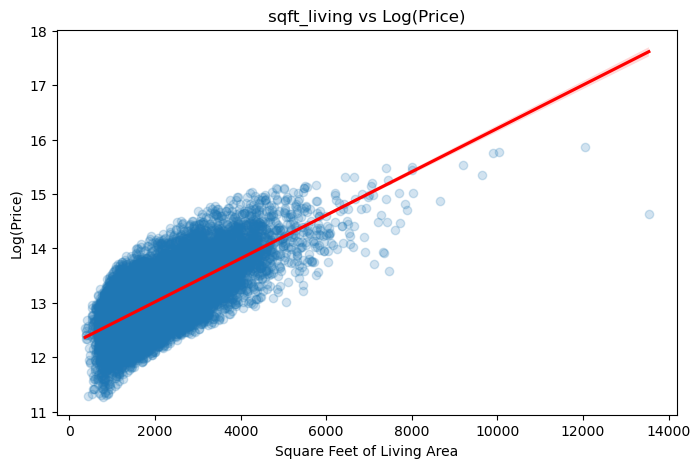

In [19]:
plt.figure(figsize=(8,5))
sns.regplot(
    x='sqft_living',
    y='log_price',
    data=df,
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)
plt.title("sqft_living vs Log(Price)")
plt.xlabel("Square Feet of Living Area")
plt.ylabel("Log(Price)")
plt.show()

There is a strong positive relationship between living area and house price. Larger homes tend to sell for higher prices.

However, in the raw price plot, variance increases with square footage, indicating heteroskedasticity. 
In contrast, the relationship between living area and log_price appears more linear and exhibits more constant variance.

This further supports the use of a log-linear modeling framework.

## House Price by Construction Grade

The variable `grade` represents overall construction quality and design. 
Higher grade homes are expected to command higher prices.

We examine how price varies across grade levels.

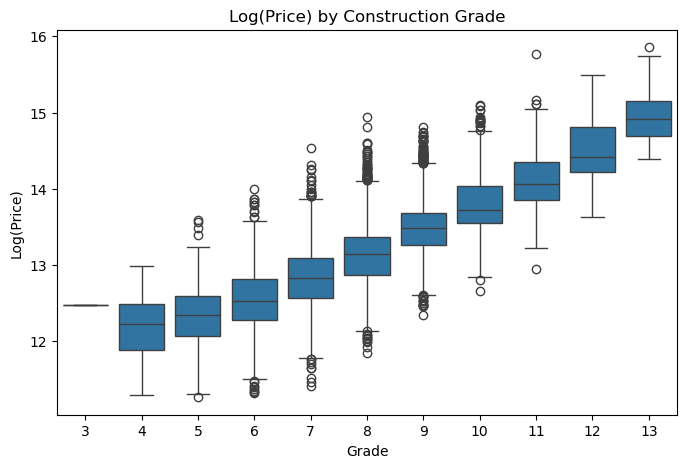

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='grade', y='log_price', data=df)
plt.title("Log(Price) by Construction Grade")
plt.xlabel("Grade")
plt.ylabel("Log(Price)")
plt.show()

There is a clear upward trend in price as construction grade increases. 
Higher-grade homes consistently show higher median prices and higher overall price distributions.

This suggests that construction quality is likely to be a strong predictor in regression models.

## House Price by Waterfront Status

Waterfront properties are typically considered premium real estate. 
We compare log-transformed prices for waterfront and non-waterfront homes.

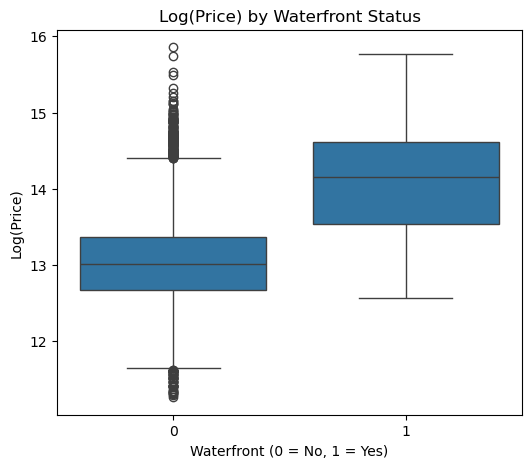

In [21]:
plt.figure(figsize=(6,5))
sns.boxplot(x='waterfront', y='log_price', data=df)
plt.title("Log(Price) by Waterfront Status")
plt.xlabel("Waterfront (0 = No, 1 = Yes)")
plt.ylabel("Log(Price)")
plt.show()

Waterfront homes exhibit substantially higher median prices compared to non-waterfront homes. 
The distribution also shows greater upper-end variability, reflecting luxury properties.

This indicates that waterfront status likely has a strong positive effect on price in regression models.

## Correlation Analysis

To better understand relationships between numeric variables, we examine the correlation matrix. 
This helps identify which variables are strongly associated with price and whether multicollinearity may be present among predictors.

We focus on the correlation between price (and log_price) and structural features such as living area, bathrooms, grade, and view.

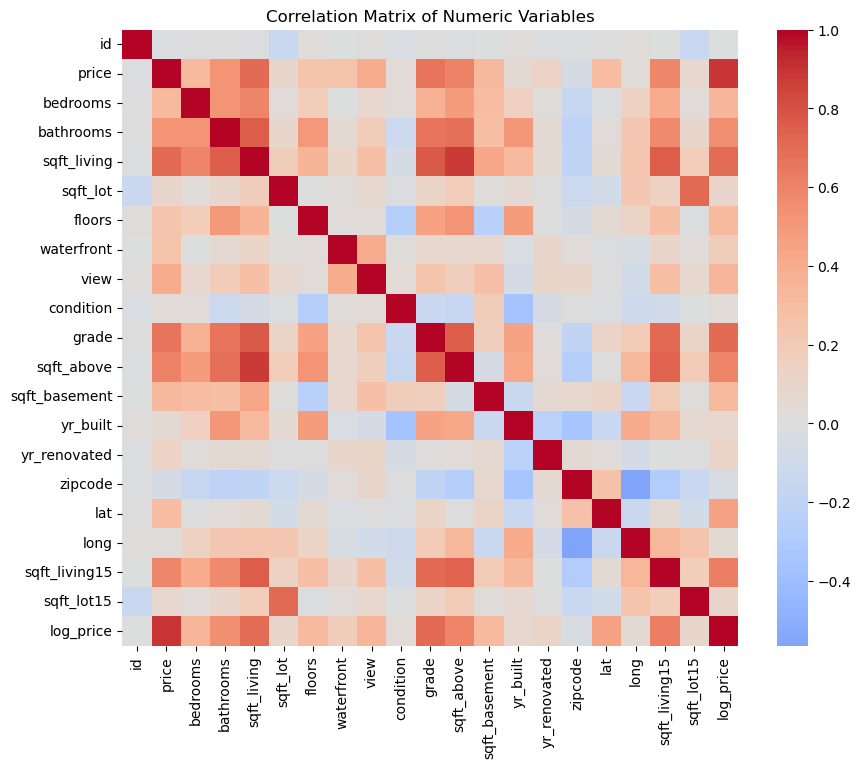

In [22]:
# select numeric variables only
numeric_df = df.select_dtypes(include=[np.number])

# compute correlation matrix
corr_matrix = numeric_df.corr()

# plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

The correlation matrix shows that `sqft_living`, `grade`, and `bathrooms` are strongly positively correlated with both price and log_price.

Living area exhibits one of the strongest correlations with price, reinforcing earlier scatterplot findings.

Some predictors are also correlated with one another (for example, sqft_living and bathrooms), suggesting that multicollinearity may need to be considered when building regression models.

# 7. Modeling

This section represents the core data science component of the project.

The following models will be estimated and compared:

1. Ordinary Least Squares (OLS) regression using log_price as the dependent variable
2. Extended OLS model with additional predictors
3. Ridge and Lasso regression with cross-validation
4. Random Forest regression model

Models will be evaluated using:

- Train/test split
- Root Mean Squared Error (RMSE)
- R²
- Cross-validation performance

For linear models, coefficient estimates will be interpreted in context. In particular, for the log-transformed model, coefficients will be translated into approximate percentage changes in price to provide meaningful economic interpretation.

## Model 1: Baseline Linear Regression (Log-Price Model)

We begin with a baseline Ordinary Least Squares (OLS) regression model using key structural variables:

- Square footage of living space (sqft_living)
- Number of bedrooms
- Number of bathrooms
- Construction grade

The dependent variable is log_price. Using a log-linear model allows coefficients to be interpreted approximately as percentage changes in price.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# define predictors and target
X = df[['sqft_living', 'bedrooms', 'bathrooms', 'grade']]
y = df['log_price']

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 15121
Testing observations: 6481


In [24]:
# fit model
lr = LinearRegression()
lr.fit(X_train, y_train)

# predictions
y_pred = lr.predict(X_test)

# evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

RMSE: 0.352
R²: 0.5675


In [25]:
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": lr.coef_
})

# convert log coefficients to approximate % change
coef_df["Approx % Change in Price"] = coef_df["Coefficient"] * 100

display(coef_df)

,Variable,Coefficient,Approx % Change in Price
0,sqft_living,0.000248,0.024778
1,bedrooms,-0.023441,-2.344140
2,bathrooms,-0.018794,-1.879410
3,grade,0.180373,18.037294


The baseline regression model explains approximately 56.8% of the variation in log house prices. 

Living area and construction grade are expected to be the strongest predictors based on both magnitude and prior economic intuition. 

An RMSE of 0.352 in log-price terms indicates moderate predictive error. While the model performs reasonably well, there is room for improvement by incorporating additional structural and location-based variables.

## Model 2: Extended Linear Regression Model

To improve predictive performance, we expand the baseline model by including additional structural and location-related variables:

- view
- waterfront
- yr_built
- latitude (lat)
- longitude (long)

These variables capture neighborhood and property quality effects that are likely important determinants of housing prices.

In [26]:
# extended predictor set
X2 = df[['sqft_living', 'bedrooms', 'bathrooms', 'grade',
         'view', 'waterfront', 'yr_built', 'lat', 'long']]

y = df['log_price']

# train/test split
X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.3, random_state=42
)

print("Training observations:", X2_train.shape[0])
print("Testing observations:", X2_test.shape[0])

Training observations: 15121
Testing observations: 6481


In [27]:
# fit extended model
lr2 = LinearRegression()
lr2.fit(X2_train, y_train)

# predictions
y2_pred = lr2.predict(X2_test)

# evaluation
rmse2 = np.sqrt(mean_squared_error(y_test, y2_pred))
r2_2 = r2_score(y_test, y2_pred)

print("Extended Model RMSE:", round(rmse2, 4))
print("Extended Model R²:", round(r2_2, 4))

Extended Model RMSE: 0.266
Extended Model R²: 0.753


In [28]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Extended"],
    "RMSE": [rmse, rmse2],
    "R²": [r2, r2_2]
})

display(comparison)

,Model,RMSE,R²
0,Baseline,0.351954,0.567528
1,Extended,0.265960,0.753045


The extended model substantially improves predictive performance relative to the baseline model.

The R² increases from 0.568 to 0.753, meaning the extended model explains approximately 75.3% of the variation in log house prices. 

The RMSE also decreases from 0.352 to 0.266, indicating improved out-of-sample prediction accuracy.

The inclusion of location variables (latitude and longitude), property view, waterfront status, and year built significantly enhances model performance. This suggests that both structural characteristics and geographic location are critical determinants of housing prices.

In [29]:
coef_extended = pd.DataFrame({
    "Variable": X2.columns,
    "Coefficient": lr2.coef_
})

coef_extended["Approx % Change in Price"] = coef_extended["Coefficient"] * 100

display(coef_extended.sort_values(by="Approx % Change in Price", ascending=False))

,Variable,Coefficient,Approx % Change in Price
7,lat,1.336610,133.661042
5,waterfront,0.405668,40.566813
3,grade,0.184063,18.406328
2,bathrooms,0.087406,8.740641
4,view,0.065244,6.524395
8,long,0.053590,5.358994
0,sqft_living,0.000181,0.018092
6,yr_built,-0.003832,-0.383218
1,bedrooms,-0.015498,-1.549830


The extended model reveals several important insights:

- Waterfront properties are associated with approximately 40% higher prices, holding other variables constant. This confirms the premium associated with waterfront location.

- Construction grade has a strong positive effect. A one-unit increase in grade is associated with roughly an 18% increase in price, all else equal.

- Additional bathrooms increase price by approximately 8–9%.

- Geographic location (latitude and longitude) plays a major role. The large coefficient on latitude reflects strong spatial price gradients across King County.

Interestingly, the coefficient on bedrooms is slightly negative when controlling for living area and other factors. This suggests that, conditional on square footage, simply adding more bedrooms without increasing overall space may reduce perceived value.

The coefficient on sqft_living appears small because it reflects the effect of a one-square-foot increase. 

Specifically, each additional square foot increases price by approximately 0.018%. 

More meaningfully, a 100-square-foot increase in living area is associated with roughly a 1.8% increase in house price, holding other variables constant.

## Predicted vs Actual Values (Extended Model)

To visually assess model performance, we compare predicted log prices with actual log prices on the test set. 

A well-performing model should produce points that closely follow the 45-degree line.

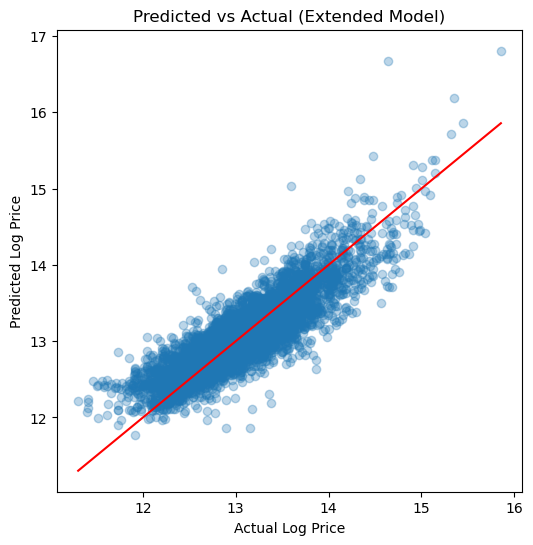

In [30]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y2_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Predicted vs Actual (Extended Model)")
plt.show()

The predicted values closely follow the 45-degree line, indicating strong agreement between predicted and actual prices. 

While some dispersion remains, the extended model captures a substantial portion of price variation, consistent with the R² value of approximately 0.75.

## Model 3: Random Forest Regressor

To further improve predictive accuracy and compare modeling approaches, we estimate a Random Forest regression model.

Unlike linear regression, Random Forest is a non-parametric ensemble learning method that can capture nonlinear relationships and complex interactions between variables.

We evaluate its performance using the same train/test split for comparability.

In [31]:
from sklearn.ensemble import RandomForestRegressor

# initialize model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# fit model using same extended feature set
rf.fit(X2_train, y_train)

# predictions
y_rf_pred = rf.predict(X2_test)

# evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test, y_rf_pred))
r2_rf = r2_score(y_test, y_rf_pred)

print("Random Forest RMSE:", round(rmse_rf, 4))
print("Random Forest R²:", round(r2_rf, 4))

Random Forest RMSE: 0.1861
Random Forest R²: 0.8791


In [32]:
comparison_full = pd.DataFrame({
    "Model": ["Baseline OLS", "Extended OLS", "Random Forest"],
    "RMSE": [rmse, rmse2, rmse_rf],
    "R²": [r2, r2_2, r2_rf]
})

display(comparison_full)

,Model,RMSE,R²
0,Baseline OLS,0.351954,0.567528
1,Extended OLS,0.265960,0.753045
2,Random Forest,0.186068,0.879128


The Random Forest model substantially outperforms both linear regression models.

Its R² increases to approximately 0.879, meaning it explains nearly 88% of the variation in log house prices. The RMSE also drops to 0.186, indicating much stronger predictive accuracy.

This improvement suggests that nonlinear relationships and complex interactions between housing characteristics play an important role in determining prices. While linear regression provides interpretability, the Random Forest model offers superior predictive performance.

In [33]:
# feature importance
importance = pd.DataFrame({
    "Variable": X2.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance)

,Variable,Importance
3,grade,0.324566
7,lat,0.319178
0,sqft_living,0.215041
8,long,0.068417
6,yr_built,0.035793
4,view,0.012974
2,bathrooms,0.010153
5,waterfront,0.007367
1,bedrooms,0.006511


Feature importance results indicate that living area, geographic location (latitude/longitude), and construction grade are among the most influential predictors of house prices in the Random Forest model.

# 8. Model Diagnostics & Selection

To evaluate model performance, we compared baseline OLS, extended OLS, and Random Forest models using out-of-sample RMSE and R².

The predicted vs actual plot for the extended linear model shows strong alignment along the 45-degree line, indicating good predictive calibration.

Comparative results show that:

- The baseline model explains approximately 57% of variation.
- The extended model improves performance to approximately 75%.
- The Random Forest model achieves the strongest performance, explaining nearly 88% of variation in log house prices.

Based on predictive accuracy metrics, the Random Forest model is selected as the best-performing model. However, the extended linear regression model remains valuable for interpretability and economic insight.

# 9. Conclusions & Limitations

## Conclusions

This project examined which structural and location-related features most strongly predict residential housing prices in King County, Washington.

The exploratory analysis revealed that living area, construction grade, waterfront status, and geographic location are strongly associated with higher house prices. The log transformation of price improved distributional symmetry and supported the use of a log-linear modeling framework.

The baseline linear regression model explained approximately 57% of the variation in log house prices. Expanding the model to include additional structural and geographic variables increased explanatory power to approximately 75%. This demonstrates the importance of both property characteristics and spatial location in determining housing values.

The Random Forest model achieved the strongest predictive performance, explaining nearly 88% of the variation in log prices and producing the lowest RMSE. This indicates that nonlinear relationships and complex interactions between variables play a substantial role in housing price determination.

Overall, while linear regression provides clear interpretability of individual effects, the Random Forest model offers superior predictive accuracy. For prediction-focused applications, the Random Forest model would be preferred. For interpretability and economic insight, the extended linear model remains valuable.

## Limitations

Several limitations should be acknowledged. First, the dataset reflects housing transactions from a specific time period and geographic region, limiting external generalizability. Second, the analysis does not account for broader macroeconomic factors such as interest rates or market cycles. Third, while the Random Forest model improves predictive accuracy, it sacrifices interpretability relative to linear regression.

Future research could incorporate additional neighborhood-level variables or temporal market indicators to further improve predictive performance.